In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcdefaults()
plt.style.use('seaborn-v0_8-paper')
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})

from ttcrpy.rgrid import Grid2d

# Grid2d (OpenCL) – GPU Speed-up vs Grid Size

This notebook benchmarks the OpenCL GPU-accelerated Fast-Sweeping Method (FSM)
against its CPU counterpart for a **homogeneous 2D medium** as the grid grows
from a few thousand cells to one million cells.

In a homogeneous medium (constant slowness) every cell has the same value,
so the analytical traveltime from any source to any point is simply
$$t(x,z) = \sqrt{(x-x_s)^2+(z-z_s)^2}\;/\;v,$$
which lets us validate correctness alongside the timing.

Two scenarios are benchmarked:

| `cell_slowness` | CPU class | GPU class |
|---|---|---|
| `True`  | `Grid2Drcfs`       | `Grid2Drcfs_OpenCL`       |
| `False` | `Grid2Drnfs`       | `Grid2Drnfs_OpenCL`       |

All runs use `dtype=np.float32` (the GPU FSM implementation requires
single precision; see the companion notebook *example_Grid2d_opencl.ipynb*
for the rationale).

In [2]:
# ── Benchmark parameters ─────────────────────────────────────────────────────
# Square N×N cell grids (cell count = N²)
grid_sizes = [50, 100, 150, 200, 300, 400, 500, 600, 800, 1000, 2000]

dx    = 10.0       # cell size (m) – same in x and z
vel   = 1.5        # homogeneous velocity (km/s)
n_rep = 3          # repetitions per size; minimum is kept as the timing result

## Correctness check

Before the full benchmark we verify that CPU and GPU give the same answer
and that both match the analytical solution on a 200 × 200 cell grid.

In [3]:
N_check = 200
xn_c = np.arange(0, (N_check + 1) * dx, dx, dtype=np.float32)
zn_c = np.arange(0, (N_check + 1) * dx, dx, dtype=np.float32)

s_val = np.float32(1.0 / vel)
s_cells = np.full(N_check * N_check,       s_val, dtype=np.float32)
s_nodes = np.full((N_check + 1) ** 2,      s_val, dtype=np.float32)

# Source at the grid centre; dense receiver grid at every node
xs, zs = N_check * dx / 2.0, N_check * dx / 2.0
src_c  = np.array([[xs, zs]], dtype=np.float32)

xi, zi = np.meshgrid(xn_c, zn_c, indexing='ij')
rcv_all = np.column_stack([xi.ravel(), zi.ravel()]).astype(np.float32)
tt_analytic = np.sqrt((rcv_all[:, 0] - xs)**2 +
                      (rcv_all[:, 1] - zs)**2) / vel

for cs, s_arr, label in [
        (True,  s_cells, 'cell_slowness=True  (Drcfs)'),
        (False, s_nodes, 'cell_slowness=False (Drnfs)')]:

    g_cpu = Grid2d(xn_c, zn_c, cell_slowness=cs, method='FSM',
                   weno=True, fsm_gpu=False, dtype=np.float32)
    g_cpu.set_slowness(s_arr)
    tt_cpu = g_cpu.raytrace(src_c, rcv_all)

    g_gpu = Grid2d(xn_c, zn_c, cell_slowness=cs, method='FSM',
                   weno=True, fsm_gpu=True, dtype=np.float32)
    g_gpu.set_slowness(s_arr)
    _ = g_gpu.raytrace(src_c, rcv_all)   # warm-up
    tt_gpu = g_gpu.raytrace(src_c, rcv_all)

    mask = tt_analytic > 0   # skip the source node itself
    err_cpu = np.max(np.abs(tt_cpu[mask] - tt_analytic[mask]) / tt_analytic[mask])
    err_gpu = np.max(np.abs(tt_gpu[mask] - tt_analytic[mask]) / tt_analytic[mask])
    diff_cg = np.max(np.abs(tt_cpu[mask] - tt_gpu[mask]))
    print(f'{label}  rel-err CPU={err_cpu:.2e}  rel-err GPU={err_gpu:.2e}  '
          f'max|CPU-GPU|={diff_cg:.2e}')

cell_slowness=True  (Drcfs)  rel-err CPU=8.12e-03  rel-err GPU=8.12e-03  max|CPU-GPU|=9.77e-04
cell_slowness=False (Drnfs)  rel-err CPU=8.12e-03  rel-err GPU=8.12e-03  max|CPU-GPU|=9.77e-04


---
## Benchmark loop

For each grid size and each slowness mode we:
1. Time the CPU FSM (`n_rep` repetitions, keep the minimum).
2. Create a fresh GPU grid (OpenCL kernels are compiled in the constructor),
   do one warm-up call, then time `n_rep` repetitions.

Only a single source (at the grid centre) and one receiver (near a corner)
are used.  In the FSM the full traveltime field is swept regardless of the
number of receivers, so this is representative of a typical production run.

In [4]:
results = {cs: {'cpu': [], 'gpu': []} for cs in (True, False)}

for N in grid_sizes:
    xn = np.arange(0, (N + 1) * dx, dx, dtype=np.float32)
    zn = np.arange(0, (N + 1) * dx, dx, dtype=np.float32)

    s_cells = np.full(N * N,       s_val, dtype=np.float32)
    s_nodes = np.full((N + 1)**2,  s_val, dtype=np.float32)

    src = np.array([[N * dx / 2.0, N * dx / 2.0]], dtype=np.float32)
    rcv = np.array([[dx,           dx           ]], dtype=np.float32)

    for cs, s_arr in [(True, s_cells), (False, s_nodes)]:
        # ── CPU ──────────────────────────────────────────────────────────────
        g_cpu = Grid2d(xn, zn, cell_slowness=cs, method='FSM',
                       weno=True, fsm_gpu=False, dtype=np.float32)
        g_cpu.set_slowness(s_arr)
        t_cpu = []
        for _ in range(n_rep):
            t0 = time.perf_counter()
            g_cpu.raytrace(src, rcv)
            t_cpu.append(time.perf_counter() - t0)
        results[cs]['cpu'].append(np.min(t_cpu))

        # ── GPU ──────────────────────────────────────────────────────────────
        g_gpu = Grid2d(xn, zn, cell_slowness=cs, method='FSM',
                       weno=True, fsm_gpu=True, dtype=np.float32)
        g_gpu.set_slowness(s_arr)
        g_gpu.raytrace(src, rcv)   # warm-up
        t_gpu = []
        for _ in range(n_rep):
            t0 = time.perf_counter()
            g_gpu.raytrace(src, rcv)
            t_gpu.append(time.perf_counter() - t0)
        results[cs]['gpu'].append(np.min(t_gpu))

    tag_rc = 'Drcfs'
    tag_rn = 'Drnfs'
    su_rc = results[True ]['cpu'][-1] / results[True ]['gpu'][-1]
    su_rn = results[False]['cpu'][-1] / results[False]['gpu'][-1]
    print(f'N={N:5d}  {tag_rc}: CPU={results[True ]["cpu"][-1]:.3f}s '
          f'GPU={results[True ]["gpu"][-1]:.3f}s  speed-up={su_rc:.1f}x   '
          f'{tag_rn}: CPU={results[False]["cpu"][-1]:.3f}s '
          f'GPU={results[False]["gpu"][-1]:.3f}s  speed-up={su_rn:.1f}x')

N=   50  Drcfs: CPU=0.013s GPU=0.070s  speed-up=0.2x   Drnfs: CPU=0.012s GPU=0.070s  speed-up=0.2x
N=  100  Drcfs: CPU=0.051s GPU=0.123s  speed-up=0.4x   Drnfs: CPU=0.050s GPU=0.123s  speed-up=0.4x
N=  150  Drcfs: CPU=0.114s GPU=0.180s  speed-up=0.6x   Drnfs: CPU=0.113s GPU=0.180s  speed-up=0.6x
N=  200  Drcfs: CPU=0.202s GPU=0.250s  speed-up=0.8x   Drnfs: CPU=0.202s GPU=0.249s  speed-up=0.8x
N=  300  Drcfs: CPU=0.456s GPU=0.367s  speed-up=1.2x   Drnfs: CPU=0.455s GPU=0.371s  speed-up=1.2x
N=  400  Drcfs: CPU=0.813s GPU=0.505s  speed-up=1.6x   Drnfs: CPU=0.811s GPU=0.526s  speed-up=1.5x
N=  500  Drcfs: CPU=1.271s GPU=0.636s  speed-up=2.0x   Drnfs: CPU=1.265s GPU=0.650s  speed-up=1.9x
N=  600  Drcfs: CPU=1.834s GPU=0.761s  speed-up=2.4x   Drnfs: CPU=1.828s GPU=0.786s  speed-up=2.3x
N=  800  Drcfs: CPU=3.270s GPU=1.083s  speed-up=3.0x   Drnfs: CPU=3.254s GPU=1.114s  speed-up=2.9x
N= 1000  Drcfs: CPU=5.137s GPU=1.354s  speed-up=3.8x   Drnfs: CPU=5.105s GPU=1.381s  speed-up=3.7x
N= 2000  D

---
## Results

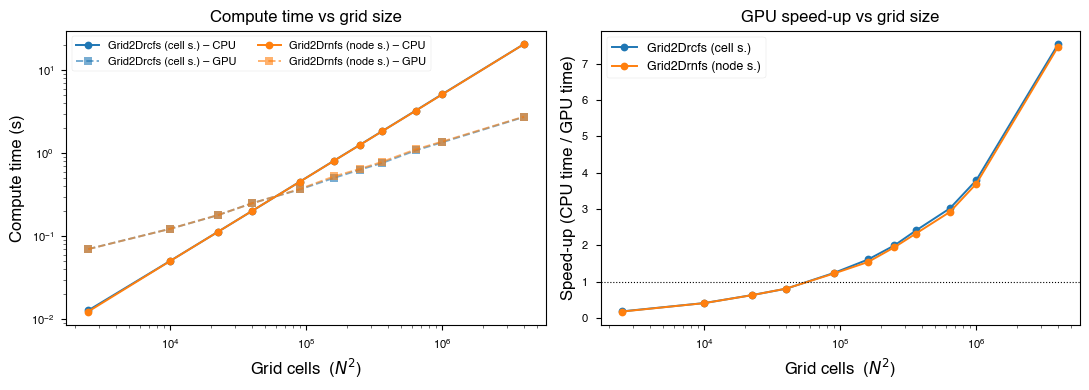

In [5]:
sizes = np.array(grid_sizes)
ncells = sizes ** 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

styles = {True:  {'label': 'Grid2Drcfs (cell s.)', 'color': 'C0'},
          False: {'label': 'Grid2Drnfs (node s.)', 'color': 'C1'}}

# ── Left: compute time ────────────────────────────────────────────────────────
ax = axes[0]
for cs in (True, False):
    c = styles[cs]['color']
    lbl = styles[cs]['label']
    ax.plot(ncells, results[cs]['cpu'], 'o-',  color=c,         label=f'{lbl} – CPU')
    ax.plot(ncells, results[cs]['gpu'], 's--', color=c, alpha=0.6, label=f'{lbl} – GPU')

ax.set_xlabel('Grid cells  ($N^2$)', fontsize=12)
ax.set_ylabel('Compute time (s)', fontsize=12)
ax.set_title('Compute time vs grid size', fontsize=12)
ax.legend(fontsize=8, ncol=2)
ax.set_xscale('log')
ax.set_yscale('log')

# ── Right: speed-up ───────────────────────────────────────────────────────────
ax = axes[1]
for cs in (True, False):
    c = styles[cs]['color']
    lbl = styles[cs]['label']
    speedup = np.array(results[cs]['cpu']) / np.array(results[cs]['gpu'])
    ax.plot(ncells, speedup, 'o-', color=c, label=lbl)

ax.axhline(1, color='k', lw=0.8, ls=':')
ax.set_xlabel('Grid cells  ($N^2$)', fontsize=12)
ax.set_ylabel('Speed-up (CPU time / GPU time)', fontsize=12)
ax.set_title('GPU speed-up vs grid size', fontsize=12)
ax.legend(fontsize=9)
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('figs/Grid2d_opencl_scaling.pdf', bbox_inches='tight')
plt.show()

In [6]:
print(f'Speed-up at maximum grid size (N={grid_sizes[-1]}, {grid_sizes[-1]**2:,} cells)\n')
for cs in (True, False):
    su = results[cs]['cpu'][-1] / results[cs]['gpu'][-1]
    name = 'Grid2Drcfs_OpenCL' if cs else 'Grid2Drnfs_OpenCL'
    print(f'  {name}: {su:.1f}x')

Speed-up at maximum grid size (N=2000, 4,000,000 cells)

  Grid2Drcfs_OpenCL: 7.5x
  Grid2Drnfs_OpenCL: 7.5x
